In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from core.GraphCreator import GraphCreator
from core.PlotGraph import plotGraph
import core.PlotGraph
from importlib import reload

In [2]:
output = pd.read_csv("output.csv")
inputs = pd.read_csv("config/atomicInputs.csv")
inputs.set_index("node", inplace=True)
display(output)

,node,SCT
0,crystal_chronicles:bronchus_planks,1.25
1,suppsquared:item_shelf_jungle,0.63
2,crystal_chronicles:holy_marble_slab,0.00
3,born_in_chaos_v1:great_reaper_axe,15305.00
4,protection_pixel:hellsnakeas_chestplate,2530.66
...,...,...
3535,minecraft:rib_armor_trim_smithing_template,542.60
3536,minecraft:diamond,80.00
3537,minecraft:diamond_block,720.00
3538,born_in_chaos_v1:diamond_termite_shard,8.89


# Outliers

In [101]:
display(output[output["SCT"] > 1e7])

,node,SCT


In [3]:
with open('fullGraph-solved.gpickle', 'rb') as f:
    gc : GraphCreator = pickle.load(f)

for n,data in gc.G.nodes.data():
    if data["type"] == "cycle":
        for subnode,subdata in data["subgraph"].nodes.data():
            gc.originalGraph.nodes[subnode]["SCT"] = subdata["SCT"]
            if "originalSCT" in subdata:
                print(n,subnode,subdata["originalSCT"])
    else:
        gc.originalGraph.nodes[n]["SCT"] = data["SCT"]


cycle-0 Ingredient@316d790a {0.3}
cycle-1 sophisticatedbackpacks:stonecutter_upgrade {75.39}
cycle-1 sophisticatedstorage:stonecutter_upgrade {7.04}
cycle-1 crafting-sophisticatedstorage:storage_stonecutter_upgrade_from_backpack_stonecutter_upgrade {4.15}
cycle-1 crafting-sophisticatedstorage:backpack_stonecutter_upgrade_from_storage_stonecutter_upgrade {72.5}
cycle-2 somemoreblocks:netherite_bricks {4329.72}
cycle-2 somemoreblocks:cut_netherite {4329.72}
cycle-3 smithing-hazennstuff:smithing/armor/lemon_god/lemon_god_boots {1818.26}
cycle-3 Ingredient@1417039a {2.05}
cycle-4 crafting-hazennstuff:crafting/materials/permafrost_shard_from_permafrost_fragment {91.95}
cycle-4 irons_spellbooks:permafrost_shard {44373.0}
cycle-5 smithing-hazennstuff:smithing/cosmetic/armor/netherite_battlemage/giorno_giovanna/giorno_giovanna_boots {2.3000000000000003}
cycle-5 Ingredient@c372b0fa {1087.8}
cycle-5 smithing-hazennstuff:smithing/cosmetic/armor/netherite_battlemage/atlas/atlas_boots {1.1400000000

In [4]:
tofind = "#music_discs"
#print(gc.nodeToCycle[tofind])

In [5]:
def neighborhood(G,source,n):
    nodes = {source}
    for _ in range(n):
        for node in nodes.copy():
            nodes.update(set(list(G.predecessors(node))))
    return nx.subgraph(G,nodes)

In [6]:
from pyvis.network import Network

def plot(G, name, fixedInOut=True):
    g = Network(width="80%", height=1000, directed=True, select_menu=True, filter_menu=True, layout=True, notebook=False)
    g.show_buttons(["physics","layout"])
    g.options.edges.smooth.enabled = False
    G = cleanupGraph(G)
    g.from_nx(G.copy())


    # Get source and sink nodes
    for n in g.nodes:
        nid = n["id"]
        n["size"] = G.nodes[nid].get("size", 30)
        n["color"] = G.nodes[nid].get("color", "gray") if nid not in inputs.index else "red"
        n["shape"] = G.nodes[nid].get("shape", "circle")
        n["font"] = {"size":10}
        n["title"] = G.nodes[nid].get("SCT", "")

    for e in g.edges:
        src, dst = e['from'], e['to']
        weight = G[src][dst].get("weight", 0)
        e['label'] = str(weight)
        e["font"] = {"size": 15, "color": "black"}
        e['arrows'] = 'to'
        e['arrowStrikethrough'] = False
        e['width'] = 1 + 2 * np.log10(weight+1)
        e['smooth'] = False

    #g.barnes_hut(spring_strength=1, spring_length=1000, overlap=1)
    g.options.layout.hierarchical.enabled = fixedInOut
    g.options.layout.hierarchical.sortMethod = "hubsize"
    g.show(f"{name}.html", notebook=False)

def cleanupGraph(G):
    G = G.copy()
    for n,data in G.nodes.data():
        if data["type"] == "cycle":
            del G.nodes[n]["subgraph"]
        G.nodes[n].update(sanitize(data))
    return G

def sanitize(obj):
    if isinstance(obj, set):
        return list(obj)
    if isinstance(obj, dict):
        return {k: sanitize(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [sanitize(v) for v in obj]
    return obj

plot(neighborhood(gc.originalGraph, tofind, 30), tofind.split(":")[-1].replace("/","_"), fixedInOut=True)

#music_discs.html


# Distribution

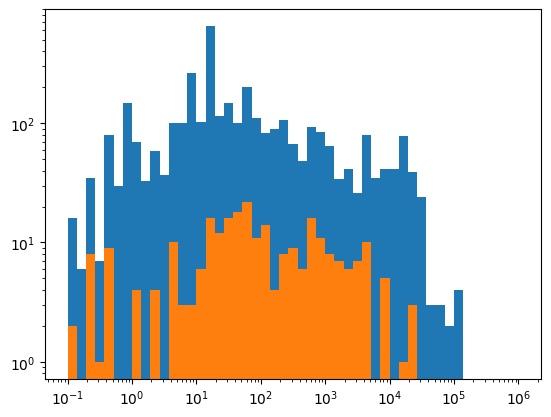

In [41]:
plt.figure()
plt.hist(output['SCT'],bins=np.geomspace(0.1, 1e6, 50))
plt.hist(inputs['value'],bins=np.geomspace(0.1, 1e6, 50))
plt.xscale('log')
plt.yscale('log')
plt.show()

In [52]:
gc.nodeToCycle["minecraft:lava"]
print(gc.G.nodes["cycle-128"]["subgraph"].nodes)

['Ingredient@2b44347f', 'create:splashing-create:splashing/gravel', 'crafting-create:polished_cut_tuff_stairs', 'crafting-create:polished_cut_tuff_slab_recycling', 'stonecutting-create:polished_cut_tuff_from_stone_types_tuff_stonecutting', 'Ingredient@e354b5c6', 'create:cut_tuff_slab', 'Ingredient@8e372ca1', 'create:small_tuff_bricks', 'smelting-create:smelting/scoria', 'stonecutting-create:small_tuff_brick_stairs_from_stone_types_tuff_stonecutting', 'create:cut_tuff_brick_slab', 'Ingredient@f4cb0ca2', 'Ingredient@ec568126', 'create:cut_tuff_stairs', 'Ingredient@37bc8aba', 'stonecutting-create:cut_tuff_slab_from_stone_types_tuff_stonecutting', 'smelting-minecraft:stone', 'Ingredient@ec2245a1', 'Ingredient@32ecdf91', 'crafting-create:cut_tuff_brick_slab_recycling', 'create:crushing-create:crushing/tuff_recycling', 'crafting-create:cut_tuff_brick_stairs', 'create:crushing-create:crushing/tuff', 'create:polished_cut_tuff', '#sands', 'stonecutting-create:polished_cut_tuff_slab_from_stone_t